# 1. Introduction and research question

We study whether oil price increases have different effects on financial markets depending on whether they are more closely associated with demand conditions or with a residual non-demand-related component.

The notebook keeps the empirical strategy deliberately simple. The main analysis is monthly, the oil decomposition is reduced-form, and the predictive regressions are interpreted as forecasting relationships rather than full causal identification.

# 2. Imports and setup

We use a short list of standard libraries and a small set of helper functions stored in `src/project_main.py`.

In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from statsmodels.tsa.api import VAR

SRC_PATH = Path("../src")
if not SRC_PATH.exists():
    SRC_PATH = Path("src")
if str(SRC_PATH.resolve()) not in sys.path:
    sys.path.insert(0, str(SRC_PATH.resolve()))

from project_main import (
    DAILY_COLUMNS,
    MONTHLY_COLUMNS,
    add_regime_variables,
    aggregate_daily_to_monthly,
    build_project_variables,
    decompose_oil_returns,
    fit_predictive_regression,
    granger_pvalue_table,
    interpret_two_component_model,
    load_data_sheet,
    regression_results_table,
    rolling_forecast_comparison,
    run_adf_table,
)

warnings.filterwarnings("ignore")
plt.style.use("default")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", "{:.4f}".format)

DATA_PATH = Path("../data/raw/data_hec_projet_1.xlsx")
if not DATA_PATH.exists():
    DATA_PATH = Path("data/raw/data_hec_projet_1.xlsx")

print("Excel file found:", DATA_PATH.exists())

Excel file found: True


# 3. Data loading

We load the daily market sheet and the monthly macro sheet, then check the sample ranges.

In [2]:
daily_raw = load_data_sheet(DATA_PATH, "Daily", DAILY_COLUMNS)  # donnees de marche journalieres
monthly_raw = load_data_sheet(DATA_PATH, "Monthly", MONTHLY_COLUMNS)  # donnees macro mensuelles

print("Daily shape:", daily_raw.shape)
print("Monthly shape:", monthly_raw.shape)
print("Daily range:", daily_raw["date"].min(), "to", daily_raw["date"].max())
print("Monthly range:", monthly_raw["date"].min(), "to", monthly_raw["date"].max())

Daily shape: (9443, 14)
Monthly shape: (435, 9)
Daily range: 1990-01-01 00:00:00 to 2026-03-11 00:00:00
Monthly range: 1989-12-31 00:00:00 to 2026-02-28 00:00:00


# 4. Data cleaning and monthly aggregation

We convert the daily market data to one observation per month by keeping the last available observation of each month. We also compute monthly realized S&P 500 volatility from daily log returns.

In [3]:
monthly_market_data = aggregate_daily_to_monthly(daily_raw)  # passage du daily au monthly
monthly_merged = (
    monthly_market_data.merge(monthly_raw, on="date", how="inner")  # on garde les mois communs
    .sort_values("date")
    .reset_index(drop=True)
)

print("Monthly market shape:", monthly_market_data.shape)
print("Merged monthly shape:", monthly_merged.shape)
display(monthly_merged.head())

Monthly market shape: (435, 15)
Merged monthly shape: (434, 23)


,date,wti,brent,bcom_energy,tft,natgas,sp500,msci_world,msci_em,russell2000,us10y,us2y,hy_ytw,gold,sp500_realized_vol,ip,cfnai,ism_mfg,ism_prices,ism_services,ism_services_prices,retail_sales,richmond_fed
0,1990-01-31,22.6800,19.5700,78.7102,NaN,NaN,329.0800,539.9400,221.2700,153.3330,8.4180,8.2540,16.5300,415.0500,0.0113,61.7290,-0.2300,47.2000,47.2000,NaN,NaN,NaN,NaN
1,1990-02-28,21.5400,19.4700,76.6323,NaN,NaN,331.8900,515.8900,229.7600,157.7990,8.5150,8.4220,17.0500,407.7000,0.0073,62.2896,0.5500,49.1000,49.1000,NaN,NaN,NaN,NaN
2,1990-03-31,20.2800,18.5900,73.9827,NaN,NaN,339.9400,483.8200,197.8500,163.6900,8.6280,8.6220,16.9500,368.5000,0.0069,62.5999,0.1700,49.9000,49.9000,NaN,NaN,NaN,NaN
3,1990-04-30,18.5400,17.5100,68.3758,NaN,1.5650,330.8000,475.9200,210.6600,158.1570,9.0220,8.9440,17.5000,367.7500,0.0068,62.4359,-0.7100,50.0000,50.0000,NaN,NaN,NaN,NaN
4,1990-05-31,17.4000,16.2800,64.6391,NaN,1.5900,361.2300,525.1000,227.6000,169.0610,8.5990,8.4820,17.6600,363.0500,0.0068,62.6258,0.0200,49.5000,49.5000,NaN,NaN,NaN,NaN


# 5. Variable construction

We create monthly log returns for the main asset prices, the term spread, the monthly change in high-yield yield-to-worst, and simple macro growth measures.

In [4]:
project_df = build_project_variables(monthly_merged)

key_columns = [
    "date",
    "wti_return",
    "brent_return",
    "sp500_return",
    "hy_change",
    "term_spread",
    "gold_return",
    "sp500_realized_vol",
    "cfnai",
    "ism_mfg",
    "ip_growth",
    "retail_sales_growth",
]

print("Project dataset shape:", project_df.shape)
display(project_df[key_columns].head(12))


Check of expected columns after variable construction:
wti_return: OK
brent_return: OK
sp500_return: OK
msci_em_return: OK
msci_world_return: OK
russell2000_return: OK
gold_return: OK
term_spread: OK
hy_change: OK
sp500_realized_vol: OK
cfnai: OK
ism_mfg: OK
ip_growth: OK
retail_sales_growth: OK
Project dataset shape: (434, 35)


,date,wti_return,brent_return,sp500_return,hy_change,term_spread,gold_return,sp500_realized_vol,cfnai,ism_mfg,ip_growth,retail_sales_growth
0,1990-01-31,NaN,NaN,NaN,NaN,0.1640,NaN,0.0113,-0.2300,47.2000,NaN,NaN
1,1990-02-28,-0.0516,-0.0051,0.0085,0.5200,0.0930,-0.0179,0.0073,0.5500,49.1000,0.0090,NaN
2,1990-03-31,-0.0603,-0.0463,0.0240,-0.1000,0.0060,-0.1011,0.0069,0.1700,49.9000,0.0050,NaN
3,1990-04-30,-0.0897,-0.0599,-0.0273,0.5500,0.0780,-0.0020,0.0068,-0.7100,50.0000,-0.0026,NaN
4,1990-05-31,-0.0635,-0.0728,0.0880,0.1600,0.1170,-0.0129,0.0068,0.0200,49.5000,0.0030,NaN
5,1990-06-30,-0.0191,0.0152,-0.0089,-0.7400,0.1920,-0.0303,0.0082,-0.0400,49.2000,0.0034,NaN
6,1990-07-31,0.1923,0.1881,-0.0052,-0.3700,0.4620,0.0555,0.0079,-0.5800,46.6000,-0.0017,NaN
7,1990-08-31,0.2780,0.2629,-0.0991,1.1100,0.7830,0.0407,0.0158,-0.2200,46.1000,0.0035,NaN
8,1990-09-30,0.3689,0.3660,-0.0525,1.9700,0.8080,0.0519,0.0099,-0.8000,44.5000,0.0001,NaN
9,1990-10-31,-0.1147,-0.1242,-0.0067,1.2600,0.8840,-0.0734,0.0143,-0.9200,43.2000,-0.0059,NaN


# 6. Descriptive statistics and stationarity

We keep the descriptive section short: one summary table, one correlation matrix, one compact figure, and ADF tests.

In [5]:
descriptive_columns = [
    "wti_return",
    "sp500_return",
    "hy_change",
    "term_spread",
    "gold_return",
    "sp500_realized_vol",
    "cfnai",
    "ism_mfg",
]

summary_table = project_df[descriptive_columns].describe().T
summary_table["skew"] = project_df[descriptive_columns].skew()
summary_table["kurtosis"] = project_df[descriptive_columns].kurtosis()
summary_table = summary_table[["count", "mean", "std", "min", "25%", "50%", "75%", "max", "skew", "kurtosis"]].round(4)

print("Table 1. Summary statistics")
display(summary_table)

print("Table 2. Correlation matrix")
display(project_df[descriptive_columns].corr().round(3))

Table 1. Summary statistics


,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
wti_return,433.0000,0.0025,0.1042,-0.7819,-0.0574,0.0088,0.0639,0.6333,-0.6062,10.4182
sp500_return,433.0000,0.0070,0.0426,-0.1856,-0.0175,0.0120,0.0341,0.1194,-0.7368,1.4837
hy_change,433.0000,-0.0227,0.6492,-2.9900,-0.2900,-0.0500,0.2300,4.7600,1.1138,11.0203
term_spread,434.0000,0.9980,0.9085,-1.0587,0.2356,0.8679,1.8062,2.8099,0.1825,-1.0299
gold_return,433.0000,0.0059,0.0439,-0.1850,-0.0214,0.0015,0.0311,0.1557,0.0615,0.9431
sp500_realized_vol,434.0000,0.0095,0.0060,0.0025,0.0059,0.0081,0.0113,0.0593,3.3617,18.9490
cfnai,434.0000,-0.0733,1.1138,-18.2600,-0.2875,0.0100,0.2400,6.3000,-9.7041,167.8761
ism_mfg,434.0000,52.2048,4.8842,34.5000,49.0000,52.5500,55.7000,63.8000,-0.5241,0.4938


Table 2. Correlation matrix


,wti_return,sp500_return,hy_change,term_spread,gold_return,sp500_realized_vol,cfnai,ism_mfg
wti_return,1.0000,0.2040,-0.2810,0.0090,0.1390,-0.3140,0.1970,0.1360
sp500_return,0.2040,1.0000,-0.6120,-0.0480,0.0190,-0.3790,-0.0020,0.0520
hy_change,-0.2810,-0.6120,1.0000,-0.0840,-0.1330,0.3750,0.0130,0.0740
term_spread,0.0090,-0.0480,-0.0840,1.0000,-0.0070,0.0580,-0.0360,0.1400
gold_return,0.1390,0.0190,-0.1330,-0.0070,1.0000,0.0190,-0.0580,-0.0300
sp500_realized_vol,-0.3140,-0.3790,0.3750,0.0580,0.0190,1.0000,-0.3180,-0.3550
cfnai,0.1970,-0.0020,0.0130,-0.0360,-0.0580,-0.3180,1.0000,0.3420
ism_mfg,0.1360,0.0520,0.0740,0.1400,-0.0300,-0.3550,0.3420,1.0000


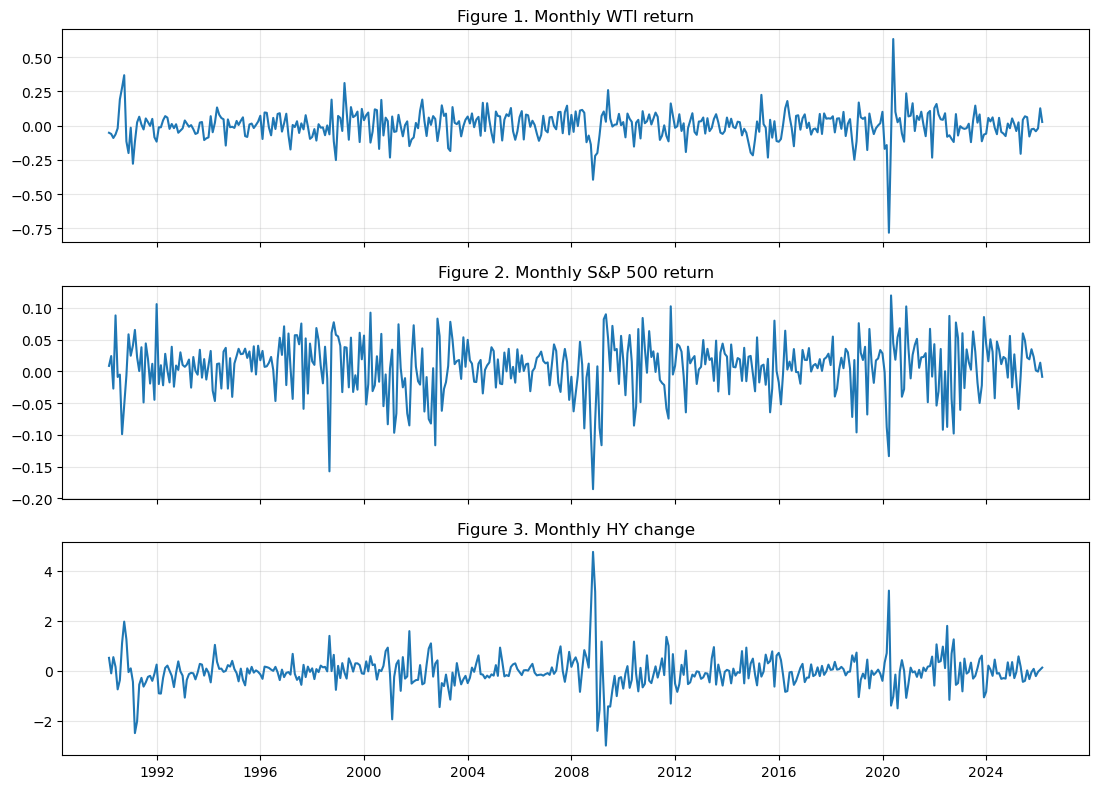

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)

series_to_plot = [
    ("wti_return", "Figure 1. Monthly WTI return"),
    ("sp500_return", "Figure 2. Monthly S&P 500 return"),
    ("hy_change", "Figure 3. Monthly HY change"),
]

for ax, (column, title) in zip(axes, series_to_plot):
    ax.plot(project_df["date"], project_df[column])
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
stationarity_columns = ["wti_return", "sp500_return", "hy_change", "term_spread", "gold_return", "cfnai", "ism_mfg"]
adf_table = run_adf_table(project_df, stationarity_columns)

print("Table 3. ADF tests")
display(adf_table)
print("Phillips-Perron is omitted to keep the notebook simple.")

Table 3. ADF tests


,variable,n_obs,adf_stat,p_value,stationary_5pct
0,wti_return,433,-12.2010,0.0000,True
1,sp500_return,433,-20.6803,0.0000,True
2,hy_change,433,-10.4457,0.0000,True
3,term_spread,434,-3.3442,0.0130,True
4,gold_return,433,-3.3210,0.0140,True
5,cfnai,434,-15.2059,0.0000,True
6,ism_mfg,434,-5.6506,0.0000,True


Phillips-Perron is omitted to keep the notebook simple.


# 7. Oil shock decomposition

We use a simple reduced-form decomposition of monthly WTI returns. The fitted value from a regression on CFNAI is interpreted as the demand-related component, while the residual is interpreted as the non-demand-related component. We also create a simple regime specification based on ISM above or below 50.

In [8]:
decomposition_df, cfnai_decomp_model = decompose_oil_returns(
    project_df,
    oil_return_col="wti_return",
    activity_col="cfnai",
    prefix="baseline",
)

decomposition_df = add_regime_variables(
    decomposition_df,
    oil_col="wti_return",
    ism_col="ism_mfg",
)

print("Table 4. Oil decomposition with CFNAI")
display(regression_results_table(cfnai_decomp_model))

reconstruction_gap = (
    decomposition_df["wti_return"]
    - decomposition_df["baseline_oil_demand_component"]
    - decomposition_df["baseline_oil_supply_component"]
).dropna()
print("Maximum reconstruction gap:", reconstruction_gap.abs().max())

Table 4. Oil decomposition with CFNAI


,coef,std_err,t_stat,p_value
const,0.0038,0.0049,0.7809,0.4353
cfnai,0.0184,0.0044,4.1777,0.0000


Maximum reconstruction gap: 0.0


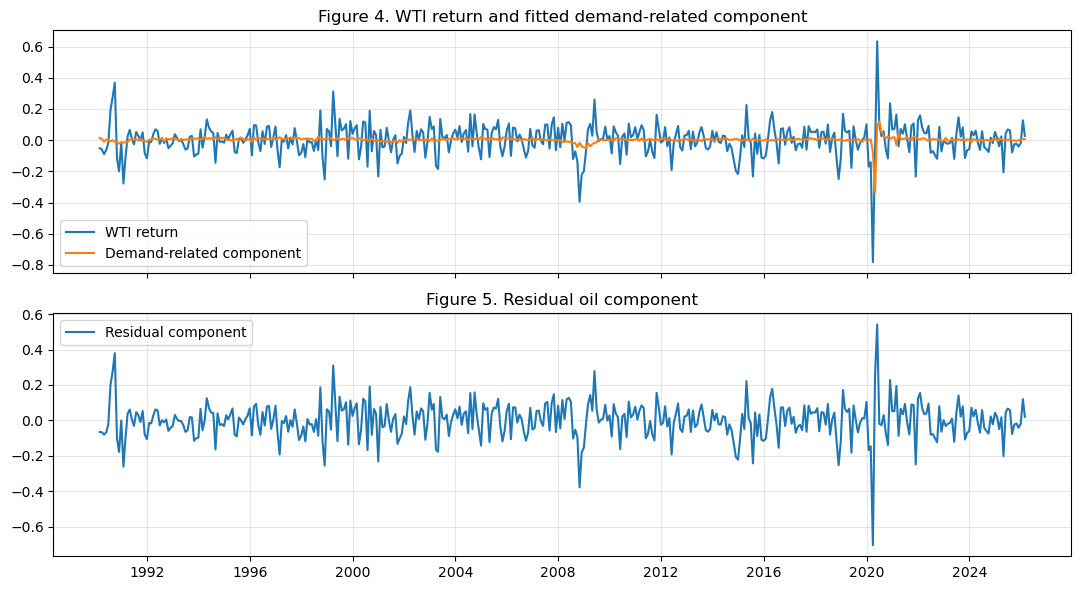

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

axes[0].plot(decomposition_df["date"], decomposition_df["wti_return"], label="WTI return")
axes[0].plot(decomposition_df["date"], decomposition_df["baseline_oil_demand_component"], label="Demand-related component")
axes[0].set_title("Figure 4. WTI return and fitted demand-related component")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(decomposition_df["date"], decomposition_df["baseline_oil_supply_component"], label="Residual component")
axes[1].set_title("Figure 5. Residual oil component")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 8. Predictive regressions

We estimate one-month-ahead regressions for S&P 500 returns and HY changes. The baseline model uses the demand-related and residual oil components. We also estimate a simple regime-based alternative.

In [10]:
def print_pair_interpretation(model, variables, labels):
    for variable, label in zip(variables, labels):
        coef = model.params.get(variable, np.nan)
        p_value = model.pvalues.get(variable, np.nan)
        sign = "positive" if coef > 0 else "negative"
        significance = "significant" if p_value < 0.05 else "not significant"
        print(f"{label}: {sign}, {significance}, p-value = {p_value:.4f}")

target_map = {
    "sp500_return": "S&P 500 next-month return",
    "hy_change": "HY next-month change",
}

decomposition_models = {}

for target, label in target_map.items():
    decomp_model, decomp_sample = fit_predictive_regression(
        decomposition_df,
        dependent_col=target,
        predictor_cols=[
            "baseline_oil_demand_component",
            "baseline_oil_supply_component",
            target,
            "term_spread",
            "gold_return",
            "sp500_realized_vol",
        ],
        horizon=1,
        cov_type="HC1",
    )
    decomposition_models[target] = decomp_model

    print(f"Decomposition model: {label}")
    print("Sample size:", len(decomp_sample))
    display(regression_results_table(decomp_model))
    print_pair_interpretation(
        decomp_model,
        ["baseline_oil_demand_component", "baseline_oil_supply_component"],
        ["Demand-related oil effect", "Residual oil effect"],
    )
    print()

Decomposition model: S&P 500 next-month return
Sample size: 432


,coef,std_err,t_stat,p_value
const,0.0110,0.0062,1.7674,0.0772
baseline_oil_demand_component,0.0090,0.1357,0.0662,0.9472
baseline_oil_supply_component,-0.0377,0.0254,-1.4813,0.1385
sp500_return_current,0.0067,0.0638,0.1043,0.9169
term_spread,-0.0012,0.0022,-0.5559,0.5783
gold_return,-0.0420,0.0530,-0.7923,0.4282
sp500_realized_vol,-0.2694,0.6068,-0.4440,0.6570


Demand-related oil effect: positive, not significant, p-value = 0.9472
Residual oil effect: negative, not significant, p-value = 0.1385

Decomposition model: HY next-month change
Sample size: 432


,coef,std_err,t_stat,p_value
const,0.1336,0.1060,1.2613,0.2072
baseline_oil_demand_component,0.9152,1.7373,0.5268,0.5983
baseline_oil_supply_component,0.8835,0.3773,2.3418,0.0192
hy_change_current,0.3221,0.0986,3.2682,0.0011
term_spread,-0.0420,0.0332,-1.2655,0.2057
gold_return,-0.0612,1.0029,-0.0610,0.9514
sp500_realized_vol,-11.5419,11.1668,-1.0336,0.3013


Demand-related oil effect: positive, not significant, p-value = 0.5983
Residual oil effect: positive, significant, p-value = 0.0192



In [11]:
for target, label in target_map.items():
    regime_model, regime_sample = fit_predictive_regression(
        decomposition_df,
        dependent_col=target,
        predictor_cols=[
            "oil_expansion",
            "oil_contraction",
            target,
            "term_spread",
            "gold_return",
            "sp500_realized_vol",
        ],
        horizon=1,
        cov_type="HC1",
    )

    print(f"Regime model: {label}")
    print("Sample size:", len(regime_sample))
    display(regression_results_table(regime_model))

Regime model: S&P 500 next-month return
Sample size: 432


,coef,std_err,t_stat,p_value
const,0.0131,0.0061,2.1577,0.0309
oil_expansion,0.0020,0.0323,0.0632,0.9496
oil_contraction,-0.0732,0.0389,-1.8820,0.0598
sp500_return_current,-0.0084,0.0642,-0.1310,0.8958
term_spread,-0.0013,0.0022,-0.6022,0.5470
gold_return,-0.0440,0.0537,-0.8200,0.4122
sp500_realized_vol,-0.5040,0.6113,-0.8244,0.4097


Regime model: HY next-month change
Sample size: 432


,coef,std_err,t_stat,p_value
const,0.1195,0.1103,1.0839,0.2784
oil_expansion,0.4011,0.4288,0.9354,0.3496
oil_contraction,1.3498,0.6281,2.1489,0.0316
hy_change_current,0.3186,0.0982,3.2432,0.0012
term_spread,-0.0416,0.0332,-1.2553,0.2094
gold_return,-0.0594,1.0143,-0.0586,0.9533
sp500_realized_vol,-9.5183,11.5346,-0.8252,0.4093


# 9. Granger causality tests

We keep this section limited to the four most relevant pairs in the project.

In [12]:
granger_specs = [
    ("baseline_oil_demand_component", "sp500_return"),
    ("baseline_oil_supply_component", "sp500_return"),
    ("baseline_oil_demand_component", "hy_change"),
    ("baseline_oil_supply_component", "hy_change"),
]

granger_tables = [granger_pvalue_table(decomposition_df, cause, effect, max_lag=3) for cause, effect in granger_specs]
print("Table 5. Granger causality p-values")
display(pd.concat(granger_tables, ignore_index=True))

Table 5. Granger causality p-values


,cause,effect,lag,p_value
0,baseline_oil_demand_component,sp500_return,1,0.6812
1,baseline_oil_demand_component,sp500_return,2,0.6780
2,baseline_oil_demand_component,sp500_return,3,0.9375
3,baseline_oil_supply_component,sp500_return,1,0.0652
4,baseline_oil_supply_component,sp500_return,2,0.0842
5,baseline_oil_supply_component,sp500_return,3,0.1690
6,baseline_oil_demand_component,hy_change,1,0.1577
7,baseline_oil_demand_component,hy_change,2,0.6904
8,baseline_oil_demand_component,hy_change,3,0.0050
9,baseline_oil_supply_component,hy_change,1,0.0013


# 10. VAR and impulse responses

As a compact extension, we estimate a reduced-form VAR and keep only the two most useful impulse responses.

In [13]:
var_columns = ["wti_return", "sp500_return", "hy_change", "term_spread", "gold_return", "ism_mfg"]
var_df = decomposition_df[["date"] + var_columns].dropna().set_index("date")

var_model = VAR(var_df)
lag_selection = var_model.select_order(maxlags=6)
lag_choice = lag_selection.selected_orders["bic"]
if lag_choice == 0:
    lag_choice = max(1, lag_selection.selected_orders["aic"])

print("Table 6. VAR lag choice")
display(pd.DataFrame([lag_selection.selected_orders], index=["selected_lag"]))
print("Chosen lag:", lag_choice)

var_results = var_model.fit(lag_choice)

Table 6. VAR lag choice


,aic,bic,hqic,fpe
selected_lag,1,1,1,1


Chosen lag: 1


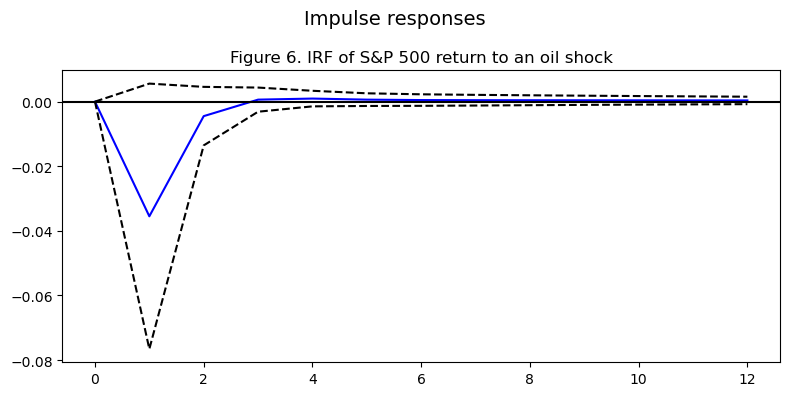

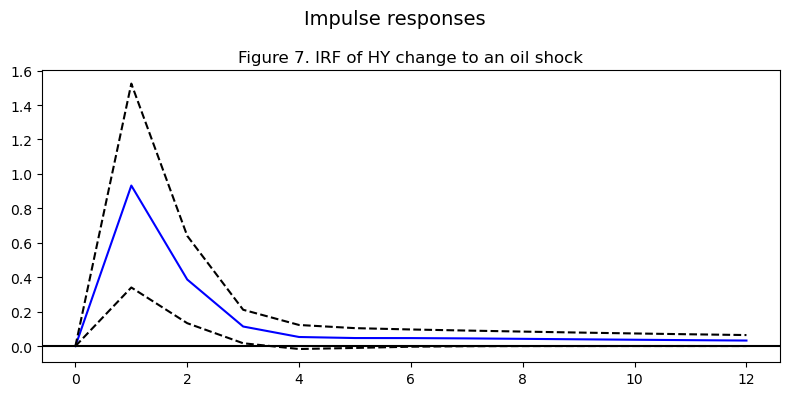

In [14]:
irf = var_results.irf(12)

fig1 = irf.plot(impulse="wti_return", response="sp500_return")
fig1.set_size_inches(8, 4)
fig1.axes[0].set_title("Figure 6. IRF of S&P 500 return to an oil shock")
plt.tight_layout()
plt.show()

fig2 = irf.plot(impulse="wti_return", response="hy_change")
fig2.set_size_inches(8, 4)
fig2.axes[0].set_title("Figure 7. IRF of HY change to an oil shock")
plt.tight_layout()
plt.show()

# 11. Out-of-sample exercise

We compare a historical-mean benchmark, a raw-oil model, and a decomposition model. We keep only the forecast accuracy table.

In [15]:
for target, label in target_map.items():
    _, metrics_df = rolling_forecast_comparison(
        decomposition_df,
        target_col=target,
        raw_oil_col="wti_return",
        demand_col="baseline_oil_demand_component",
        supply_col="baseline_oil_supply_component",
        controls=["term_spread", "gold_return", "sp500_realized_vol"],
        start_share=0.6,
    )
    print(f"Forecast comparison: {label}")
    display(metrics_df)

Forecast comparison: S&P 500 next-month return


,model,rmse,mae
0,benchmark,0.0404,0.0308
1,raw_oil_model,0.0417,0.0312
2,decomposition_model,0.0436,0.0318


Forecast comparison: HY next-month change


,model,rmse,mae
0,benchmark,0.5526,0.3816
1,raw_oil_model,0.5814,0.4027
2,decomposition_model,0.5845,0.4047


# 12. Robustness checks

We keep the robustness section short and focused: Brent instead of WTI, ISM instead of CFNAI, and MSCI EM instead of the S&P 500.

In [16]:
robustness_rows = []

brent_df, _ = decompose_oil_returns(decomposition_df, oil_return_col="brent_return", activity_col="cfnai", prefix="brent")
brent_model, brent_sample = fit_predictive_regression(
    brent_df,
    dependent_col="sp500_return",
    predictor_cols=["brent_oil_demand_component", "brent_oil_supply_component", "sp500_return", "term_spread", "gold_return", "sp500_realized_vol"],
    horizon=1,
    cov_type="HC1",
)
robustness_rows.append({
    "check": "Brent instead of WTI",
    "sample_size": len(brent_sample),
    "component_1": brent_model.params.get("brent_oil_demand_component", np.nan),
    "component_1_pvalue": brent_model.pvalues.get("brent_oil_demand_component", np.nan),
    "component_2": brent_model.params.get("brent_oil_supply_component", np.nan),
    "component_2_pvalue": brent_model.pvalues.get("brent_oil_supply_component", np.nan),
})

ism_df, _ = decompose_oil_returns(decomposition_df, oil_return_col="wti_return", activity_col="ism_mfg", prefix="ism")
ism_model, ism_sample = fit_predictive_regression(
    ism_df,
    dependent_col="sp500_return",
    predictor_cols=["ism_oil_demand_component", "ism_oil_supply_component", "sp500_return", "term_spread", "gold_return", "sp500_realized_vol"],
    horizon=1,
    cov_type="HC1",
)
robustness_rows.append({
    "check": "ISM instead of CFNAI",
    "sample_size": len(ism_sample),
    "component_1": ism_model.params.get("ism_oil_demand_component", np.nan),
    "component_1_pvalue": ism_model.pvalues.get("ism_oil_demand_component", np.nan),
    "component_2": ism_model.params.get("ism_oil_supply_component", np.nan),
    "component_2_pvalue": ism_model.pvalues.get("ism_oil_supply_component", np.nan),
})

em_model, em_sample = fit_predictive_regression(
    decomposition_df,
    dependent_col="msci_em_return",
    predictor_cols=["baseline_oil_demand_component", "baseline_oil_supply_component", "msci_em_return", "term_spread", "gold_return", "sp500_realized_vol"],
    horizon=1,
    cov_type="HC1",
)
robustness_rows.append({
    "check": "MSCI EM instead of S&P 500",
    "sample_size": len(em_sample),
    "component_1": em_model.params.get("baseline_oil_demand_component", np.nan),
    "component_1_pvalue": em_model.pvalues.get("baseline_oil_demand_component", np.nan),
    "component_2": em_model.params.get("baseline_oil_supply_component", np.nan),
    "component_2_pvalue": em_model.pvalues.get("baseline_oil_supply_component", np.nan),
})

print("Table 7. Robustness checks")
display(pd.DataFrame(robustness_rows).round(4))

Table 7. Robustness checks


,check,sample_size,component_1,component_1_pvalue,component_2,component_2_pvalue
0,Brent instead of WTI,432,0.0108,0.9587,-0.0431,0.1258
1,ISM instead of CFNAI,432,-0.0021,0.9907,-0.0366,0.1491
2,MSCI EM instead of S&P 500,432,0.1636,0.2628,-0.0573,0.0803


# 13. Main conclusions

The main message of the notebook should be read in a reduced-form sense. The fitted oil component is interpreted as demand-related, while the residual component is interpreted as non-demand-related. The project is designed to provide a transparent and coherent empirical framework rather than a full structural identification strategy.

In [17]:
print("Main takeaway for S&P 500 returns")
for line in interpret_two_component_model(
    decomposition_models["sp500_return"],
    "baseline_oil_demand_component",
    "baseline_oil_supply_component",
):
    print(line)

print("
Main takeaway for HY changes")
for line in interpret_two_component_model(
    decomposition_models["hy_change"],
    "baseline_oil_demand_component",
    "baseline_oil_supply_component",
):
    print(line)

SyntaxError: unterminated string literal (detected at line 9) (3261163058.py, line 9)